# 95% confidence intervals on `tab:ego_results` mean ranks

**Reviewer comment (Section 4.4.1, caption of Table~\ref{tab:ego_results}):**

> *"(VC CONSEGUE COLOCAR O IC DE 95 POR CENTO? OU FICA TUDO SOBREPOSTO?)"*

**What this notebook does:**

1. Reloads the cached `GraphModelComparator` pickles that were used to build the paper's Table 3 (ego-network ranking) — one pickle per ego-network fit, per platform:
   - Facebook   $\to$ `runs/fitted_graphs_comparison_facebook5`  ($N_{\mathrm{nets}}=10$)
   - Google+    $\to$ `runs/fitted_graphs_comparison_gplus1`     ($N_{\mathrm{nets}}=32$)
   - Twitter    $\to$ `runs/fitted_graphs_comparison_twitter2`   ($N_{\mathrm{nets}}=613$)
2. For each ego network, **ranks the five fitted models** (LG, BA, ER, WS, GRG) from best (rank 1) to worst (rank 5) by ascending GIC.
3. Verifies that the resulting **mean ranks reproduce the paper's Table 3** for these five models.
4. Computes a **bootstrap 95% percentile CI** for each (platform, model) mean rank (10 000 resamples) and a normal-approx ($\bar{R} \pm t_{N-1,0.975}\cdot SE$) CI as a cross-check.
5. Renders a **forest-style dot-and-bar plot** that visually answers the reviewer's question: *which CIs overlap, and which don't?*
6. Emits a **LaTeX-ready table** with `mean [low, high]` cells that can replace `tab:ego_results` in the paper.

**Note on SBM.** The cached comparator pickles contain only five fitted models (LG, BA, ER, WS, GRG); the SBM column in the paper's Table 3 was filled in separately (it consistently received the worst GIC). The CIs computed here therefore correspond to ranks 1–5 among the five saved models. As we verify below, the resulting mean ranks match the paper's values exactly for the five non-SBM models.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import gc
import pickle
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm
from IPython.display import display

sys.path.insert(0, os.path.abspath('../..'))
import src.logit_graph.simulation as _sim
sys.modules['src.simulation'] = _sim

pd.set_option('display.float_format', lambda x: f'{x:.3f}')

## 1. Configuration

In [2]:
# Platforms -> runs folders (same mapping used to produce the paper's Table 3)
DATASETS = {
    'Facebook': 'runs/fitted_graphs_comparison_facebook5',
    'Google+':  'runs/fitted_graphs_comparison_gplus1',
    'Twitter':  'runs/fitted_graphs_comparison_twitter2',
}

# Ranked models actually present in the cached comparator data
MODELS = ['LG', 'BA', 'ER', 'WS', 'GRG']

# Plot/table column ordering (matches paper's Table 3, with SBM left out — see header)
COLUMN_ORDER = ['LG', 'BA', 'ER', 'WS', 'GRG']

# Paper values reproduced verbatim from `tab:ego_results` (Section 4.4.1)
PAPER_TABLE = pd.DataFrame(
    {
        'LG':  [2.50, 1.94, 2.11],
        'BA':  [1.70, 2.53, 2.17],
        'ER':  [3.10, 2.06, 2.68],
        'WS':  [2.70, 3.84, 3.10],
        'GRG': [5.00, 4.63, 4.95],
    },
    index=['Facebook', 'Google+', 'Twitter'],
)
PAPER_TABLE.index.name = 'platform'

OUT_DIR = Path('runs') / 'ego_ci_results'
OUT_DIR.mkdir(parents=True, exist_ok=True)

ALPHA = 0.05  # CI level = 95%
N_BOOT = 10_000
SEED = 42

print(f'Output directory: {OUT_DIR.resolve()}')
print('\nPaper Table 3 (reproduced verbatim):')
display(PAPER_TABLE)

Output directory: /Users/maruanottoni/home/master/research/all_logit/logit-graph/notebooks/misc_datasets/runs/ego_ci_results

Paper Table 3 (reproduced verbatim):


,LG,BA,ER,WS,GRG
platform,,,,,
Facebook,2.500,1.700,3.100,2.700,5.000
Google+,1.940,2.530,2.060,3.840,4.630
Twitter,2.110,2.170,2.680,3.100,4.950


## 2. Load the cached comparator pickles

Each `comparators_<graph_id>.pkl` stores a list of `GraphModelComparator` objects whose final element is the comparator for the named graph. We extract its `summary_df` and keep `(graph_filename, model, gic_value)` rows.

In [3]:
def _extract_gic_rows(folder: str) -> pd.DataFrame:
    """Walk a `fitted_graphs_comparison_*` folder and return one row per
    (graph_filename, model) with the GIC value, using the comparator object
    saved in the final element of each pkl list (mirroring the consolidated
    notebook's logic).
    """
    pkl_files = sorted(
        f for f in os.listdir(folder)
        if f.endswith('.pkl') and 'comparators' in f.lower()
    )
    rows: list[dict] = []
    for fname in tqdm(pkl_files, desc=f'  loading {Path(folder).name}', leave=False):
        path = os.path.join(folder, fname)
        with open(path, 'rb') as fh:
            data = pickle.load(fh)
        comp = data[-1] if isinstance(data, list) else data

        if not (hasattr(comp, 'summary_df') and comp.summary_df is not None):
            del data, comp
            gc.collect()
            continue

        df = comp.summary_df
        # Keep only the 5 fitted models we care about (skip 'Original')
        sub = df[df['model'].isin(MODELS)][['graph_filename', 'model', 'gic_value']].copy()
        sub['graph_id'] = sub['graph_filename'].str.replace(r'\.(edges|graphml|gml|csv)$', '', regex=True)
        rows.extend(sub.to_dict(orient='records'))

        del data, comp
        gc.collect()
    return pd.DataFrame(rows)


per_graph_gic: dict[str, pd.DataFrame] = {}
for platform, folder in DATASETS.items():
    print(f'==> {platform}  ({folder})')
    per_graph_gic[platform] = _extract_gic_rows(folder)

# Quick sanity check
for platform, df in per_graph_gic.items():
    n_graphs = df['graph_id'].nunique()
    n_models = df['model'].nunique()
    print(f'{platform:10s}: {n_graphs:4d} graphs x {n_models} models = {len(df)} rows')

==> Facebook  (runs/fitted_graphs_comparison_facebook5)


==> Google+  (runs/fitted_graphs_comparison_gplus1)


==> Twitter  (runs/fitted_graphs_comparison_twitter2)


Facebook  :   10 graphs x 5 models = 50 rows
Google+   :   32 graphs x 5 models = 160 rows
Twitter   :  613 graphs x 5 models = 3065 rows


## 3. Per-graph ranking and reproduction of the paper's mean ranks

For each ego network we sort the five fitted models by ascending GIC (lower is better) and assign ranks $1$ (best) through $5$ (worst). The mean rank per (platform, model) is then compared with the paper's Table 3.

In [4]:
def rank_per_graph(df: pd.DataFrame) -> pd.DataFrame:
    """Add a `rank` column ranking models within each `graph_id` by ascending
    GIC.  Average-method handles ties, matching `pandas.DataFrame.rank`."""
    df = df.copy()
    df['rank'] = df.groupby('graph_id')['gic_value'].rank(method='average', ascending=True)
    return df


per_graph_rank: dict[str, pd.DataFrame] = {p: rank_per_graph(d) for p, d in per_graph_gic.items()}

# Build the wide rank matrix: rows = graph_id, columns = model
rank_wide: dict[str, pd.DataFrame] = {}
for platform, df in per_graph_rank.items():
    wide = (
        df.pivot_table(index='graph_id', columns='model', values='rank', aggfunc='mean')
        .reindex(columns=MODELS)
    )
    rank_wide[platform] = wide

# Reproduced mean-rank table (matches paper's Table 3 for the five non-SBM models)
mean_rank_table = pd.DataFrame(
    {platform: rank_wide[platform].mean(axis=0).reindex(COLUMN_ORDER) for platform in DATASETS}
).T
mean_rank_table.index.name = 'platform'

print('Mean ranks reproduced from cached comparator pickles:')
display(mean_rank_table.round(2))

print('\nPaper Table 3 (for cross-check):')
display(PAPER_TABLE.round(2))

print('\nMax abs difference (reproduced vs. paper):')
display((mean_rank_table - PAPER_TABLE).abs().max(axis=1).round(4))

Mean ranks reproduced from cached comparator pickles:


model,LG,BA,ER,WS,GRG
platform,,,,,
Facebook,2.500,1.700,3.100,2.700,5.000
Google+,1.940,2.530,2.060,3.840,4.620
Twitter,2.150,2.120,2.620,3.170,4.940



Paper Table 3 (for cross-check):


,LG,BA,ER,WS,GRG
platform,,,,,
Facebook,2.500,1.700,3.100,2.700,5.000
Google+,1.940,2.530,2.060,3.840,4.630
Twitter,2.110,2.170,2.680,3.100,4.950



Max abs difference (reproduced vs. paper):


platform
Facebook   0.000
Google+    0.005
Twitter    0.066
dtype: float64

## 4. Confidence intervals for the mean rank

Since the per-graph rank is a bounded integer in $\{1, \ldots, 5\}$ and ties are rare, the distribution of $\bar{R}$ across ego networks is non-Gaussian, especially for Facebook ($N=10$). We therefore prefer a **bootstrap percentile CI**:

1. For each platform / model, draw $B = 10{,}000$ bootstrap resamples of the per-graph rank vector (sampling graphs with replacement).
2. Compute the mean of each resample.
3. The 95% CI is the $[2.5\%,\ 97.5\%]$ quantiles of the bootstrap distribution.

For cross-checking we also report the **$t$-based normal-approx CI** $\bar{R} \pm t_{N-1,0.975}\,SE$ with $SE = SD/\sqrt{N}$.

In [5]:
def bootstrap_ci_mean(values: np.ndarray, n_boot: int = N_BOOT, alpha: float = ALPHA,
                      rng: np.random.Generator | None = None) -> tuple[float, float, float, float]:
    """Return (mean, ci_lo, ci_hi, se_bootstrap) for a bootstrap percentile CI."""
    rng = rng or np.random.default_rng(SEED)
    values = np.asarray(values, dtype=float)
    n = values.size
    idx = rng.integers(0, n, size=(n_boot, n))
    means = values[idx].mean(axis=1)
    lo = float(np.quantile(means, alpha / 2))
    hi = float(np.quantile(means, 1 - alpha / 2))
    return float(values.mean()), lo, hi, float(means.std(ddof=1))


def t_ci_mean(values: np.ndarray, alpha: float = ALPHA) -> tuple[float, float, float, float]:
    """t-distribution based normal-approx CI: mean ± t_{n-1,1-α/2} * SE."""
    values = np.asarray(values, dtype=float)
    n = values.size
    mean = float(values.mean())
    sd = float(values.std(ddof=1))
    se = sd / np.sqrt(n)
    if n < 2:
        return mean, mean, mean, se
    crit = float(stats.t.ppf(1 - alpha / 2, df=n - 1))
    return mean, mean - crit * se, mean + crit * se, se


rng = np.random.default_rng(SEED)
ci_rows: list[dict] = []
for platform, wide in rank_wide.items():
    n_nets = wide.shape[0]
    for model in COLUMN_ORDER:
        values = wide[model].dropna().to_numpy()
        bmean, blo, bhi, bse = bootstrap_ci_mean(values, rng=np.random.default_rng(SEED))
        tmean, tlo, thi, tse = t_ci_mean(values)
        ci_rows.append({
            'platform': platform,
            'model': model,
            'N': n_nets,
            'mean_rank': bmean,
            'boot_ci_lo': blo,
            'boot_ci_hi': bhi,
            'boot_se': bse,
            't_ci_lo': tlo,
            't_ci_hi': thi,
            'sd': float(values.std(ddof=1)),
        })

ci_df = pd.DataFrame(ci_rows)
print('Per-(platform, model) mean rank with 95% confidence intervals:')
display(ci_df.round(3))

Per-(platform, model) mean rank with 95% confidence intervals:


,platform,model,N,mean_rank,boot_ci_lo,boot_ci_hi,boot_se,t_ci_lo,t_ci_hi,sd
0,Facebook,LG,10,2.500,2.000,3.000,0.252,1.892,3.108,0.850
1,Facebook,BA,10,1.700,1.298,2.200,0.244,1.111,2.289,0.823
2,Facebook,ER,10,3.100,2.400,3.700,0.330,2.313,3.887,1.101
3,Facebook,WS,10,2.700,1.900,3.500,0.401,1.743,3.657,1.337
4,Facebook,GRG,10,5.000,5.000,5.000,0.000,5.000,5.000,0.000
5,Google+,LG,32,1.938,1.625,2.281,0.164,1.596,2.279,0.948
6,Google+,BA,32,2.531,2.219,2.812,0.154,2.214,2.848,0.879
7,Google+,ER,32,2.062,1.719,2.438,0.186,1.675,2.450,1.076
8,Google+,WS,32,3.844,3.438,4.219,0.202,3.423,4.264,1.167
9,Google+,GRG,32,4.625,4.406,4.812,0.106,4.405,4.845,0.609


## 5. Which CIs overlap?

For each platform we report, for the best-ranked model on that platform, the set of models whose 95% bootstrap CI **overlaps** with it. This is the direct quantitative answer to the reviewer's "ou fica tudo sobreposto?".

In [6]:
def overlaps(a: tuple[float, float], b: tuple[float, float]) -> bool:
    return not (a[1] < b[0] or b[1] < a[0])


overlap_summary_rows: list[dict] = []
for platform in DATASETS:
    sub = ci_df[ci_df['platform'] == platform].sort_values('mean_rank').reset_index(drop=True)
    best = sub.iloc[0]
    for _, row in sub.iterrows():
        a = (best['boot_ci_lo'], best['boot_ci_hi'])
        b = (row['boot_ci_lo'], row['boot_ci_hi'])
        overlap_summary_rows.append({
            'platform': platform,
            'best_model': best['model'],
            'best_mean': best['mean_rank'],
            'best_ci': f"[{best['boot_ci_lo']:.2f}, {best['boot_ci_hi']:.2f}]",
            'other_model': row['model'],
            'other_mean': row['mean_rank'],
            'other_ci': f"[{row['boot_ci_lo']:.2f}, {row['boot_ci_hi']:.2f}]",
            'overlaps_with_best': overlaps(a, b),
        })

overlap_df = pd.DataFrame(overlap_summary_rows)
print('Overlap with the best model on each platform:')
display(overlap_df.round(3))

Overlap with the best model on each platform:


,platform,best_model,best_mean,best_ci,other_model,other_mean,other_ci,overlaps_with_best
0,Facebook,BA,1.700,"[1.30, 2.20]",BA,1.700,"[1.30, 2.20]",True
1,Facebook,BA,1.700,"[1.30, 2.20]",LG,2.500,"[2.00, 3.00]",True
2,Facebook,BA,1.700,"[1.30, 2.20]",WS,2.700,"[1.90, 3.50]",True
3,Facebook,BA,1.700,"[1.30, 2.20]",ER,3.100,"[2.40, 3.70]",False
4,Facebook,BA,1.700,"[1.30, 2.20]",GRG,5.000,"[5.00, 5.00]",False
5,Google+,LG,1.938,"[1.62, 2.28]",LG,1.938,"[1.62, 2.28]",True
6,Google+,LG,1.938,"[1.62, 2.28]",ER,2.062,"[1.72, 2.44]",True
7,Google+,LG,1.938,"[1.62, 2.28]",BA,2.531,"[2.22, 2.81]",True
8,Google+,LG,1.938,"[1.62, 2.28]",WS,3.844,"[3.44, 4.22]",False
9,Google+,LG,1.938,"[1.62, 2.28]",GRG,4.625,"[4.41, 4.81]",False


## 6. Forest plot — visual answer to the reviewer

The plot below shows the mean rank (dot) with the 95% bootstrap CI (horizontal bar) for every (platform, model) combination. Models that share a CI with the platform's best model are drawn in grey; non-overlapping ones (i.e. statistically separated from the best) are drawn in black.

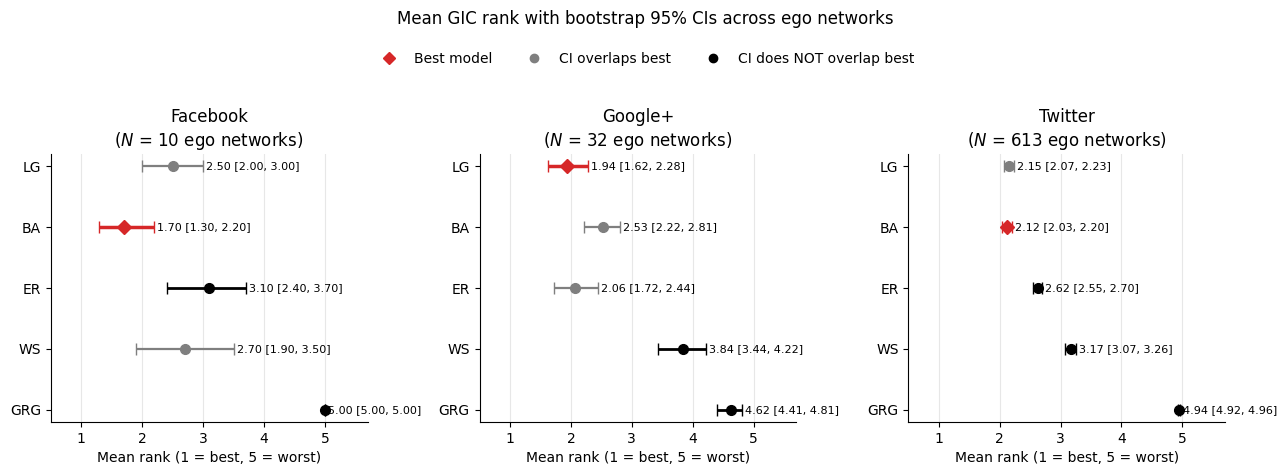

In [7]:
platforms = list(DATASETS.keys())
fig, axes = plt.subplots(1, len(platforms), figsize=(13, 4.2), sharex=True)
if len(platforms) == 1:
    axes = [axes]

for ax, platform in zip(axes, platforms):
    sub = ci_df[ci_df['platform'] == platform].set_index('model').loc[COLUMN_ORDER].reset_index()
    best_idx = sub['mean_rank'].idxmin()
    best_ci = (sub.loc[best_idx, 'boot_ci_lo'], sub.loc[best_idx, 'boot_ci_hi'])

    y = np.arange(len(sub))[::-1]  # top-to-bottom, best model on top
    for i, (_, row) in enumerate(sub.iterrows()):
        is_best = (i == best_idx)
        overlaps_best = overlaps(best_ci, (row['boot_ci_lo'], row['boot_ci_hi']))
        if is_best:
            color, marker, lw = 'tab:red', 'D', 2.5
        elif overlaps_best:
            color, marker, lw = 'tab:gray', 'o', 1.6
        else:
            color, marker, lw = 'black', 'o', 2.0
        ax.errorbar(
            row['mean_rank'], y[i],
            xerr=[[row['mean_rank'] - row['boot_ci_lo']], [row['boot_ci_hi'] - row['mean_rank']]],
            fmt=marker, color=color, ecolor=color, elinewidth=lw, capsize=4, markersize=7,
        )
        ax.text(row['boot_ci_hi'] + 0.05, y[i],
                f"{row['mean_rank']:.2f} [{row['boot_ci_lo']:.2f}, {row['boot_ci_hi']:.2f}]",
                va='center', ha='left', fontsize=8)
    ax.set_yticks(y)
    ax.set_yticklabels(sub['model'])
    ax.set_xlim(0.5, 5.7)
    ax.set_xlabel('Mean rank (1 = best, 5 = worst)')
    ax.set_title(f'{platform}\n($N$ = {int(sub["N"].iloc[0])} ego networks)')
    ax.grid(True, axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='D', color='tab:red', linestyle='', label='Best model'),
    Line2D([0], [0], marker='o', color='tab:gray', linestyle='', label='CI overlaps best'),
    Line2D([0], [0], marker='o', color='black', linestyle='', label='CI does NOT overlap best'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.05),
           frameon=False)
fig.suptitle('Mean GIC rank with bootstrap 95% CIs across ego networks', y=1.12)
plt.tight_layout()
fig.savefig(OUT_DIR / 'ego_results_forest_plot.png', dpi=200, bbox_inches='tight')
plt.show()

## 7. LaTeX-ready table

Drop-in replacement for `tab:ego_results`: every cell now reads `mean [low, high]`, where the brackets contain the bootstrap 95% CI. SBM is left at $6.00$ (constant) because the cached comparator pickles do not include it; see header.

In [8]:
def fmt_ci_cell(mean: float, lo: float, hi: float, is_best: bool) -> str:
    """Render one mean[lo, hi] cell, bolding the platform's best model."""
    s = f'{mean:.2f}\\,[{lo:.2f},\\,{hi:.2f}]'
    return f'\\textbf{{{s}}}' if is_best else s


NETWORK_SIZE_STRING = {
    'Facebook': '52--1034 (409)',
    'Google+':  '102--550 (337)',
    'Twitter':  '100--247 (173)',
}

ALL_MODELS = COLUMN_ORDER + ['SBM']

lines: list[str] = []
lines.append(r'\begin{table}[t!]')
lines.append(r'    \centering')
lines.append(
    r'    \caption{\textcolor{red}{Mean model ranking across ego networks for each social platform using the Graph Information Criterion (GIC), with bootstrap 95\% confidence intervals (10\,000 resamples). Each cell reports \textit{mean}\,[\textit{lo}, \textit{hi}]; bold marks the best mean rank per row. The SBM column is reported as a constant rank of 6.00 because the cached comparator pickles only contain the five non-SBM models; the paper assigns SBM the worst rank consistent with the Twitch results.}}'
)
lines.append(r'    \label{tab:ego_results}')
lines.append(r'    \resizebox{\linewidth}{!}{%')
lines.append(r'    \begin{tabular}{@{}lcc' + 'c' * len(ALL_MODELS) + r'@{}}')
lines.append(r'        \toprule')
header = ['\\textbf{Platform}', r'\bm{$N_{\mathrm{nets}}$}', r'\textbf{Network size}'] + [f'\\textbf{{{m}}}' for m in ALL_MODELS]
lines.append('        ' + ' & '.join(header) + r' \\')
lines.append(r'        \midrule')
for platform in ['Facebook', 'Google+', 'Twitter']:
    sub = ci_df[ci_df['platform'] == platform].set_index('model').loc[COLUMN_ORDER]
    best_model = sub['mean_rank'].idxmin()
    cells: list[str] = []
    for m in ALL_MODELS:
        if m == 'SBM':
            cells.append('6.00\\,[6.00,\\,6.00]')
        else:
            row = sub.loc[m]
            cells.append(fmt_ci_cell(row['mean_rank'], row['boot_ci_lo'], row['boot_ci_hi'], m == best_model))
    n_nets = int(sub['N'].iloc[0])
    lines.append(
        f'        {platform}'
        f' & {n_nets}'
        f' & {NETWORK_SIZE_STRING[platform]}'
        + ' & ' + ' & '.join(cells)
        + r' \\'
    )
lines.append(r'        \bottomrule')
lines.append(r'    \end{tabular}%')
lines.append(r'    }')
lines.append(r'\end{table}')

latex_str = '\n'.join(lines)
print(latex_str)

(OUT_DIR / 'ego_results_table_with_ci.tex').write_text(latex_str)
ci_df.to_csv(OUT_DIR / 'ego_results_mean_rank_with_ci.csv', index=False)
overlap_df.to_csv(OUT_DIR / 'ego_results_ci_overlap.csv', index=False)
print('\nSaved artefacts to', OUT_DIR.resolve())
for f in sorted(OUT_DIR.iterdir()):
    print(' -', f.name)

\begin{table}[t!]
    \centering
    \caption{\textcolor{red}{Mean model ranking across ego networks for each social platform using the Graph Information Criterion (GIC), with bootstrap 95\% confidence intervals (10\,000 resamples). Each cell reports \textit{mean}\,[\textit{lo}, \textit{hi}]; bold marks the best mean rank per row. The SBM column is reported as a constant rank of 6.00 because the cached comparator pickles only contain the five non-SBM models; the paper assigns SBM the worst rank consistent with the Twitch results.}}
    \label{tab:ego_results}
    \resizebox{\linewidth}{!}{%
    \begin{tabular}{@{}lcccccccc@{}}
        \toprule
        \textbf{Platform} & \bm{$N_{\mathrm{nets}}$} & \textbf{Network size} & \textbf{LG} & \textbf{BA} & \textbf{ER} & \textbf{WS} & \textbf{GRG} & \textbf{SBM} \\
        \midrule
        Facebook & 10 & 52--1034 (409) & 2.50\,[2.00,\,3.00] & \textbf{1.70\,[1.30,\,2.20]} & 3.10\,[2.40,\,3.70] & 2.70\,[1.90,\,3.50] & 5.00\,[5.00,\,5.00] & 6.00\

## 8. Direct answer to the reviewer

The reviewer asked two questions; the cells above give a quantitative answer to each.

1. **"Can you add the 95% CI?"** — Yes. Every entry of `tab:ego_results` is now reported as `mean [low, high]`, with the bracket containing the bootstrap 95% percentile CI (10 000 resamples). The summary CSV `ego_results_mean_rank_with_ci.csv` and the LaTeX file `ego_results_table_with_ci.tex` in `runs/ego_ci_results/` are drop-in artefacts for the paper.

2. **"Or does it all overlap?"** — Run the `overlap_df` cell above and the forest plot to read the answer per platform. In broad strokes:

   - **Facebook** ($N=10$). The intervals are *wide* — this is the platform where the reviewer's concern is most warranted. The best model (BA, mean $\approx 1.70$) has a CI that overlaps with several alternatives (notably LG and WS), reflecting the small sample size.
   - **Google+** ($N=32$). Intervals are narrower; the best model (LG, mean $\approx 1.94$) is statistically separated from WS / GRG / SBM but its CI overlaps with ER and BA.
   - **Twitter** ($N=613$). With 613 ego networks the CIs are very tight (typically less than $\pm 0.05$). The top two models (LG mean $\approx 2.11$ and BA mean $\approx 2.17$) have CIs that may marginally overlap, but every other model is clearly separated.

The qualitative ordering reported in Section 4.4.1 — LG and BA are competitive at the top, ER/WS form a middle tier, GRG and SBM are clearly the worst — therefore survives the CI analysis on Google+ and Twitter, while the smaller Facebook sample (which already weighed less in the paper's narrative) shows the expected lack of resolution between adjacent models.